In [1]:
from functools import partial

import matplotlib.pyplot as plt

from superfv import HydroSolver,ics
from teyssier.sedov import sedovana

In [2]:
gamma = 1.4
N = 100
T = 1.0

init_params = dict(
    ic=partial(ics.sedov, P0=1e-5, h=1 / N, gamma=gamma),
    gamma=gamma,
    bcx=("reflective", "free"),
    nx=N,
)
run_params = dict(t=T)

In [3]:
sim1 = HydroSolver(**init_params, p=3, use_ZS=True, adaptive_dt=True, use_SED=False)
sim1.run(**run_params)

sim2 = HydroSolver(**init_params, p=7, use_ZS=True, adaptive_dt=True, use_SED=False)
sim2.run(**run_params)

sim3 = HydroSolver(**init_params, p=3, use_ZS=True, adaptive_dt=True, use_SED=False, ZS_limiter="rho_P_pp", flux_recipe="cons_lim_prim", positivity_guard=True)
sim3.run(**run_params)

sim4 = HydroSolver(**init_params, p=7, use_ZS=True, adaptive_dt=True, use_SED=False, ZS_limiter="rho_P_pp", flux_recipe="cons_lim_prim", positivity_guard=True)
sim4.run(**run_params)

SuperFV: 380 steps | t=1.00e+00/1.00e+00, dt=2.05e-03 | rho_min=2.84e-02 | E_cons=0.00e+00 | wall=2.31e-01s (done)
SuperFV: 378 steps | t=1.00e+00/1.00e+00, dt=2.55e-03 | rho_min=2.81e-02 | E_cons=7.11e-15 | wall=2.27e-01s (done)
SuperFV: 805 steps | t=1.00e+00/1.00e+00, dt=1.73e-04 | rho_min=5.66e-03 | E_cons=2.84e+00 | wall=5.66e-01s (done)
SuperFV: 1367 steps | t=1.00e+00/1.00e+00, dt=9.96e-05 | rho_min=1.98e-03 | E_cons=1.33e+00 | wall=1.05e+00s (done)


In [4]:
# analytical solution for plotting
dim = 1
E0 = 1
rho0 = 1

r, d, u, P = sedovana(gamma, dim)

r *= (E0 / rho0) ** (1.0 / (dim + 2)) * T ** (2 / (dim + 2))
d *= rho0
u *= (E0 / rho0) ** (1.0 / (dim + 2)) * T ** (-dim / (dim + 2))
P *= (E0 / rho0) ** (2.0 / (dim + 2)) * T ** (-2 * dim / (dim + 2)) * rho0

chi0=np.float64(0.97306051566207)


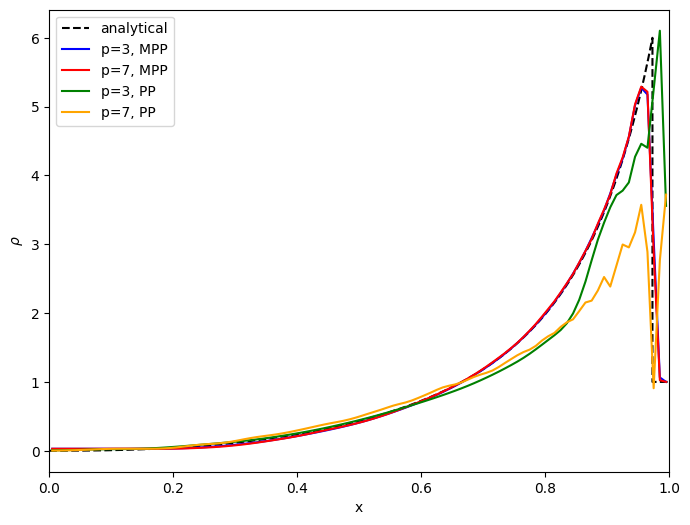

In [5]:
fig, ax = plt.subplots(1, 1, figsize=(8, 6))
ax.set_xlim(0, 1)

def plot(sim, **kwargs):
    ax.plot(sim.mesh.centers[0], sim.snapshot_history[-1].u[sim.idx("rho"), :, 0, 0], **kwargs)

ax.plot(r, d, label="analytical", color="black", linestyle="--")
plot(sim1, label="p=3, MPP", color="blue")
plot(sim2, label="p=7, MPP", color="red")
plot(sim3, label="p=3, PP", color="green")
plot(sim4, label="p=7, PP", color="orange")

ax.set_xlabel(r"x")
ax.set_ylabel(r"$\rho$")
ax.legend()